1. INNER vs LEFT JOIN

In [1]:
import pandas as pd

df1 = pd.DataFrame({
    "ID": [1, 2, 3],
    "Name": ["A", "B", "C"]
})

df2 = pd.DataFrame({
    "ID": [2, 3, 4],
    "Marks": [80, 90, 70]
})

inner = pd.merge(df1, df2, on="ID", how="inner")
left = pd.merge(df1, df2, on="ID", how="left")

print("INNER JOIN:\n", inner)
print("\nLEFT JOIN:\n", left)

INNER JOIN:
    ID Name  Marks
0   2    B     80
1   3    C     90

LEFT JOIN:
    ID Name  Marks
0   1    A    NaN
1   2    B   80.0
2   3    C   90.0


2. Rows lost in INNER JOIN

In [3]:
lost = df1[~df1["ID"].isin(inner["ID"])]
print(lost)

   ID Name
0   1    A


3. Merge 3 datasets

In [5]:
df1 = pd.DataFrame({"ID": [1, 2], "Name": ["A", "B"]})
df2 = pd.DataFrame({"ID": [1, 2], "Marks": [70, 80]})
df3 = pd.DataFrame({"ID": [1, 2], "City": ["Delhi", "Mumbai"]})

merged = df1.merge(df2, on="ID").merge(df3, on="ID")
print(merged)

   ID Name  Marks    City
0   1    A     70   Delhi
1   2    B     80  Mumbai


4. Convert release_date → datetime

In [7]:
df = pd.DataFrame({
    "Movie": ["X", "Y"],
    "Release_Date": ["2023-01-10", "2022-05-20"]
})

df["Release_Date"] = pd.to_datetime(df["Release_Date"])
print(df.dtypes)

Movie                      str
Release_Date    datetime64[us]
dtype: object


5. Extract year

In [9]:
df = pd.DataFrame({
    "Date": pd.to_datetime(["2021-03-10", "2022-07-15"])
})

df["Year"] = df["Date"].dt.year
print(df)

        Date  Year
0 2021-03-10  2021
1 2022-07-15  2022


6. Pivot table (genre vs year)

In [11]:
df = pd.DataFrame({
    "Genre": ["Action", "Action", "Drama"],
    "Year": [2022, 2023, 2022],
    "Rating": [7, 8, 9]
})

pivot = df.pivot_table(values="Rating", index="Genre", columns="Year")
print(pivot)

Year    2022  2023
Genre             
Action   7.0   8.0
Drama    9.0   NaN


7. Plot average rating by genre

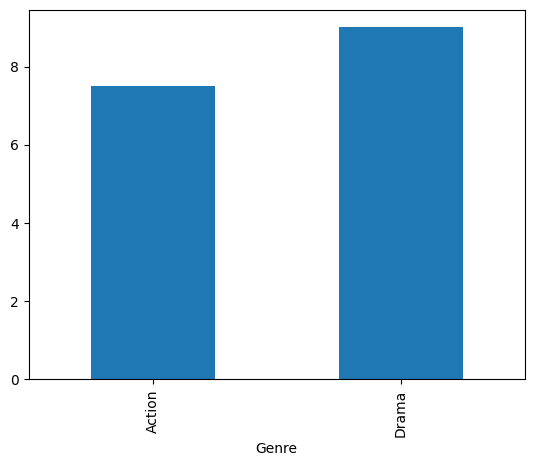

In [13]:
import matplotlib.pyplot as plt

df = pd.DataFrame({
    "Genre": ["Action", "Drama", "Action"],
    "Rating": [7, 9, 8]
})

avg = df.groupby("Genre")["Rating"].mean()
avg.plot(kind="bar")
plt.show()

8. Plot rating trend over years

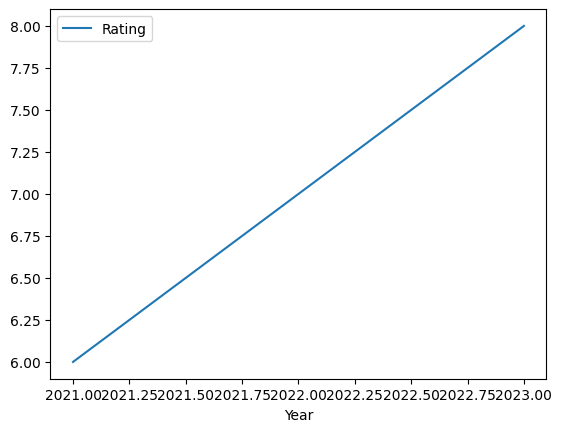

In [15]:
df = pd.DataFrame({
    "Year": [2021, 2022, 2023],
    "Rating": [6, 7, 8]
})

df.plot(x="Year", y="Rating")
plt.show()

9. Plot budget vs revenue

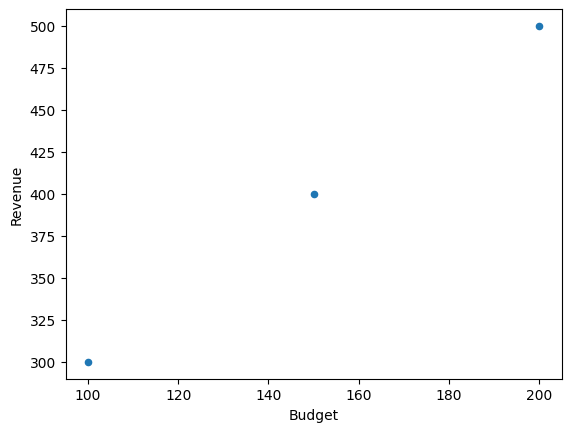

In [17]:
df = pd.DataFrame({
    "Budget": [100, 200, 150],
    "Revenue": [300, 500, 400]
})

df.plot.scatter(x="Budget", y="Revenue")
plt.show()